# Compare Regrowth Probability Across P. aeruginosa Strains

## Overview
This notebook compares regrowth fractions of S. aureus when exposed to different P. aeruginosa strains: wild-type (WT), ΔpqsL, ΔrhlA, and ΔΔrhlApqsL double mutant. It generates publication figures (2A and 2B) and performs statistical analysis.

## Analysis Workflow
1. **Load Regrowth Data**: Import merged regrowth fraction data from all four strains
2. **Spatial Profiles (Figure 2B)**: Plot regrowth probability vs distance to P. aeruginosa along y-axis
3. **Overall Comparison (Figure 2A)**: Compare mean regrowth across all bins per chamber with statistical testing

## Statistical Methods
- **Kruskal-Wallis H-test**: Non-parametric test for differences among strains
- **Dunn's post-hoc test**: Pairwise comparisons vs WT with Bonferroni correction
- **Limit of Detection (LOD)**: Zero values replaced with LOD = 0.001 for visualization on log-compatible scale

## Outputs
- `2B_regrowth_probability_yaxis.pdf`: Spatial regrowth profiles
- `2A_overall_regrowth_probability.pdf`: Overall comparison with statistics
- `mean_regrowth_summary.csv`: Summary statistics table

In [1]:
# Data analysis packages
import numpy as np
import pandas as pd
from scipy import stats
import scikit_posthocs as sp

# Visualization packages
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

# File handling
import os

# Verify working directory
print(f"Current working directory: {os.getcwd()}")
print(f"Expected to be in: .../Figure2/2A_mutants/")

Current working directory: /Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Figure_Data/Figure2/2A_mutants
Expected to be in: .../Figure2/2A_mutants/


# Figure 2B: Spatial Regrowth Profiles

Data loaded successfully!
  WT:         20 rows
  ΔpqsL:      20 rows
  ΔrhlA:      20 rows
  ΔΔrhlApqsL: 20 rows

✅ Figure saved: 2B_regrowth_probability_yaxis.pdf


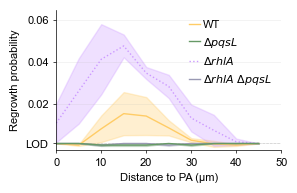

In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Matplotlib style settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 8
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Strain colors
COLORS = {
    'WT': '#ffcc66',       
    'ΔpqsL': '#669966',    
    'ΔrhlA': '#cc99ff',    
    'ΔrhlA ΔpqsL': '#9999B3' 
}

# Limit of detection
LOD = 0.001

# Output file
OUTPUT_FIGURE = '2B_regrowth_probability_yaxis.pdf'

# =============================================================================
# LOAD DATA
# =============================================================================

# Load regrowth fraction data from all strains (relative paths)
regrowth_wt = pd.read_csv('../../Figure1/1E_wt/figure_code/1_regrowth_fractions_wt_merged.csv')
regrowth_pqsL = pd.read_csv('2A_pqsL/1_regrowth_fractions_pqsL_merged.csv')
regrowth_rhlA = pd.read_csv('2A_rhlA/figure_code/1_regrowth_fractions_rhlA_merged.csv')
regrowth_rhlApqsL = pd.read_csv('2A_rhlApqsL/1_regrowth_fractions_rhlApqsL_merged.csv')

print("Data loaded successfully!")
print(f"  WT:         {len(regrowth_wt)} rows")
print(f"  ΔpqsL:      {len(regrowth_pqsL)} rows")
print(f"  ΔrhlA:      {len(regrowth_rhlA)} rows")
print(f"  ΔΔrhlApqsL: {len(regrowth_rhlApqsL)} rows")

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def extract_stats(df, axis='y'):
    """Extract mean, std, and bin positions for specified axis"""
    df_axis = df[df['axis'] == axis].copy().sort_values('bin_left')
    mean_vals = df_axis['mean_regrowth_fraction'].values
    std_vals = df_axis['std_regrowth_fraction'].values
    bin_positions = df_axis['bin_left'].values
    return mean_vals, std_vals, bin_positions

def plot_with_shade(ax, mean, std, y, label, color, linestyle='-'):
    """Plot mean ± std as line with shaded error region"""
    line = ax.plot(y, mean, label=label, color=color, linewidth=1, linestyle=linestyle)
    ax.fill_between(y, mean - std, mean + std, color=color, alpha=0.3)
    return line[0]

# =============================================================================
# EXTRACT Y-AXIS STATISTICS
# =============================================================================

wt_mean, wt_std, wt_y = extract_stats(regrowth_wt, axis='y')
pqsL_mean, pqsL_std, pqsL_y = extract_stats(regrowth_pqsL, axis='y')
rhlA_mean, rhlA_std, rhlA_y = extract_stats(regrowth_rhlA, axis='y')
rhlApqsL_mean, rhlApqsL_std, rhlApqsL_y = extract_stats(regrowth_rhlApqsL, axis='y')

# =============================================================================
# REPLACE ZERO VALUES WITH LOD
# =============================================================================

# Replace zeros with LOD for visualization (prevents log-scale issues)
wt_mean = np.where(wt_mean == 0, LOD, wt_mean)
pqsL_mean = np.where(pqsL_mean == 0, LOD, pqsL_mean)
rhlA_mean = np.where(rhlA_mean == 0, LOD, rhlA_mean)
rhlApqsL_mean = np.where(rhlApqsL_mean == 0, LOD, rhlApqsL_mean)

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig = plt.figure(figsize=(3, 2))
ax = fig.add_axes([0.20, 0.25, 0.75, 0.70])

# Plot all strains (ΔrhlA with dotted line to distinguish)
line_wt = plot_with_shade(ax, wt_mean, wt_std, wt_y, 'WT', COLORS['WT'])
line_rhlA = plot_with_shade(ax, rhlA_mean, rhlA_std, rhlA_y, 'ΔrhlA', COLORS['ΔrhlA'], linestyle=':')
line_rhlApqsL = plot_with_shade(ax, rhlApqsL_mean, rhlApqsL_std, rhlApqsL_y, 'ΔpqsL ΔrhlA', COLORS['ΔrhlA ΔpqsL'])
line_pqsL = plot_with_shade(ax, pqsL_mean, pqsL_std, pqsL_y, 'ΔpqsL', COLORS['ΔpqsL'])

# Add LOD reference line
ax.axhline(y=LOD, color='lightgray', linestyle='--', linewidth=0.5, zorder=0)

# Axes labels and limits
ax.set_xlabel('Distance to PA (µm)', fontsize=8)
ax.set_ylabel('Regrowth probability', fontsize=8)
ax.set_xlim(0, 50)
ax.set_ylim(-0.002, 0.065)
ax.set_xticks([0, 10, 20, 30, 40, 50])

# Y-axis ticks with LOD label
y_ticks = [LOD, 0.02, 0.04, 0.06]
ax.set_yticks(y_ticks)
ax.set_yticklabels(['LOD', '0.02', '0.04', '0.06'], fontsize=8)

# Style (minimal spines, subtle grid)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='both', which='major', width=0.5, length=2, labelsize=8)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Legend with italic formatting for gene names
ax.legend(
    [line_wt, line_pqsL, line_rhlA, line_rhlApqsL], 
    ['WT', r'$\it{ΔpqsL}$', r'$\it{ΔrhlA}$', r'$\it{ΔrhlA\ ΔpqsL}$'],
    frameon=False, fontsize=8, loc='upper right', 
    handlelength=1, handletextpad=0.2
)

# Save figure
plt.savefig(OUTPUT_FIGURE, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n✅ Figure saved: {OUTPUT_FIGURE}")

plt.show()

# Figure 2A: Overall Regrowth Comparison with Statistics

## Objective
Compare mean regrowth probability across entire chambers (all bins averaged) for each P. aeruginosa strain.

## Statistical Approach
1. **Per-chamber averaging**: Calculate mean regrowth fraction across all bins for each chamber
2. **Kruskal-Wallis H-test**: Non-parametric test for differences among strains (suitable for non-normal distributions)
3. **Dunn's post-hoc test**: Pairwise comparisons vs WT with Bonferroni correction for multiple testing

## Visualization
- Individual data points: All chamber means (jittered for visibility)
- Horizontal lines: Median values per strain
- Brackets and stars: Significant differences vs WT (*, p<0.05; **, p<0.01; ***, p<0.001)

Per-chamber data loaded:
  Total rows: 1100
  Strains: ['WT' 'ΔpqsL' 'ΔrhlA' 'ΔrhlA ΔpqsL']

Chamber-level statistics:
  Total chambers analyzed: 110

DESCRIPTIVE STATISTICS PER STRAIN

WT (n=23):
  Mean ± SEM: 0.0053 ± 0.0008
  Median:     0.0056

ΔpqsL (n=28):
  Mean ± SEM: 0.0001 ± 0.0001
  Median:     0.0000

ΔrhlA (n=29):
  Mean ± SEM: 0.0210 ± 0.0014
  Median:     0.0223

ΔrhlA ΔpqsL (n=30):
  Mean ± SEM: 0.0000 ± 0.0000
  Median:     0.0000

STATISTICAL ANALYSIS

1. KRUSKAL-WALLIS TEST
   (Non-parametric alternative to one-way ANOVA)
   H0: All group distributions are equal
   H-statistic: 99.3287
   p-value: 2.17e-21
   → SIGNIFICANT: At least one strain differs from others

----------------------------------------------------------------------
2. POST-HOC: DUNN'S TEST WITH BONFERRONI CORRECTION
----------------------------------------------------------------------
   (Non-parametric pairwise comparisons)

   Adjusted p-values (Bonferroni):
                   WT     ΔpqsL     Δ

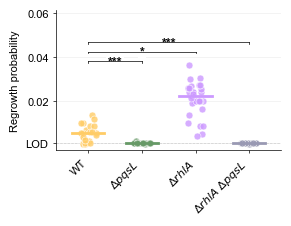


SUGGESTED METHODS TEXT

Statistical differences in regrowth probability among strains were assessed 
using the Kruskal-Wallis test, a non-parametric alternative to one-way ANOVA, 
due to non-normal data distributions and unequal variances among groups. 
Post-hoc pairwise comparisons between each mutant and wild-type were performed 
using Dunn's test with Bonferroni correction for multiple comparisons. 
Statistical analyses were performed in Python using scipy and scikit-posthocs.



In [3]:
# =============================================================================
# LOAD PER-CHAMBER DATA
# =============================================================================

# Load per-chamber regrowth data from all strains (relative paths)
regrowth_chamber_wt = pd.read_csv('../../Figure1/1E_wt/figure_code/1_regrowth_fractions_wt_per_chamber.csv')
regrowth_chamber_pqsL = pd.read_csv('2A_pqsL/1_regrowth_fractions_pqsL_per_chamber.csv')
regrowth_chamber_rhlA = pd.read_csv('2A_rhlA/figure_code/1_regrowth_fractions_rhlA_per_chamber.csv')
regrowth_chamber_rhlApqsL = pd.read_csv('2A_rhlApqsL/1_regrowth_fractions_rhlApqsL_per_chamber.csv')

# Add strain labels
regrowth_chamber_wt['strain'] = 'WT'
regrowth_chamber_pqsL['strain'] = 'ΔpqsL'
regrowth_chamber_rhlA['strain'] = 'ΔrhlA'
regrowth_chamber_rhlApqsL['strain'] = 'ΔrhlA ΔpqsL'

# Combine all datasets
all_data = pd.concat([
    regrowth_chamber_wt, 
    regrowth_chamber_pqsL, 
    regrowth_chamber_rhlA, 
    regrowth_chamber_rhlApqsL
], ignore_index=True)

# Filter for y-axis data only
y_data = all_data[all_data['axis'] == 'y'].copy()

print("Per-chamber data loaded:")
print(f"  Total rows: {len(y_data)}")
print(f"  Strains: {y_data['strain'].unique()}")

# =============================================================================
# CALCULATE MEAN REGROWTH ACROSS ALL BINS (ENTIRE CHAMBER)
# =============================================================================

# Average regrowth fraction across all bins for each chamber
chamber_means = (y_data
                .groupby(['strain', 'replicate', 'position'])['regrowth_fraction']
                .mean()
                .reset_index()
                .rename(columns={'regrowth_fraction': 'mean_regrowth_fraction'}))

print(f"\nChamber-level statistics:")
print(f"  Total chambers analyzed: {len(chamber_means)}")

# Strain order for plotting
strains_order = ['WT', 'ΔpqsL', 'ΔrhlA', 'ΔrhlA ΔpqsL']

# =============================================================================
# DESCRIPTIVE STATISTICS
# =============================================================================

print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS PER STRAIN")
print("="*70)

stats_summary = []
for strain in strains_order:
    strain_data = chamber_means[chamber_means['strain'] == strain]['mean_regrowth_fraction'].values
    n = len(strain_data)
    mean_val = np.mean(strain_data)
    std_val = np.std(strain_data, ddof=1)
    sem_val = stats.sem(strain_data)
    median_val = np.median(strain_data)
    
    stats_summary.append({
        'strain': strain,
        'n': n,
        'mean': mean_val,
        'std': std_val,
        'sem': sem_val,
        'median': median_val
    })
    
    print(f"\n{strain} (n={n}):")
    print(f"  Mean ± SEM: {mean_val:.4f} ± {sem_val:.4f}")
    print(f"  Median:     {median_val:.4f}")

stats_df = pd.DataFrame(stats_summary)

# =============================================================================
# STATISTICAL ANALYSIS - KRUSKAL-WALLIS (NON-PARAMETRIC)
# =============================================================================

print("\n" + "="*70)
print("STATISTICAL ANALYSIS")
print("="*70)

# Prepare data groups
groups = [chamber_means[chamber_means['strain'] == s]['mean_regrowth_fraction'].values 
          for s in strains_order]

# Kruskal-Wallis test
print("\n1. KRUSKAL-WALLIS TEST")
print("   (Non-parametric alternative to one-way ANOVA)")
print("   H0: All group distributions are equal")
h_stat, kw_p = stats.kruskal(*groups)
print(f"   H-statistic: {h_stat:.4f}")
print(f"   p-value: {kw_p:.2e}")
if kw_p < 0.05:
    print("   → SIGNIFICANT: At least one strain differs from others")
else:
    print("   → Not significant")

# =============================================================================
# POST-HOC: DUNN'S TEST (if Kruskal-Wallis significant)
# =============================================================================

pvalues_vs_wt = {}
if kw_p < 0.05:
    print("\n" + "-"*70)
    print("2. POST-HOC: DUNN'S TEST WITH BONFERRONI CORRECTION")
    print("-"*70)
    print("   (Non-parametric pairwise comparisons)")
    
    dunn_results = sp.posthoc_dunn(
        chamber_means, 
        val_col='mean_regrowth_fraction', 
        group_col='strain', 
        p_adjust='bonferroni'
    )
    
    print("\n   Adjusted p-values (Bonferroni):")
    print(dunn_results.round(6).to_string())
    
    print("\n   COMPARISONS vs WT:")
    for strain in strains_order:
        if strain == 'WT':
            continue
        p_val = dunn_results.loc['WT', strain]
        
        if p_val < 0.001:
            sig = "***"
        elif p_val < 0.01:
            sig = "**"
        elif p_val < 0.05:
            sig = "*"
        else:
            sig = "ns"
        
        print(f"   {strain} vs WT: p = {p_val:.2e} {sig}")
    
    # Store p-values for plotting
    pvalues_vs_wt = {strain: dunn_results.loc['WT', strain] 
                     for strain in strains_order if strain != 'WT'}

# =============================================================================
# CREATE FIGURE
# =============================================================================

print("\n" + "="*70)
print("CREATING FIGURE")
print("="*70)

OUTPUT_FIGURE = '2A_overall_regrowth_probability.pdf'

fig = plt.figure(figsize=(3, 2))
ax = fig.add_axes([0.20, 0.25, 0.75, 0.70])

# Filter strains to plot (only those with data)
strains_to_plot = [s for s in strains_order if s in chamber_means['strain'].values]
x_positions = {strain: i for i, strain in enumerate(strains_to_plot)}

# Set random seed for reproducible jitter
np.random.seed(42)

# Plot each strain
for strain in strains_to_plot:
    strain_data = chamber_means[chamber_means['strain'] == strain]['mean_regrowth_fraction'].values
    x_pos = x_positions[strain]
    
    # Replace zeros with LOD for visualization
    plot_data = np.where(strain_data == 0, LOD, strain_data)
    
    # Plot individual data points (jittered)
    jitter = np.random.uniform(-0.15, 0.15, len(plot_data))
    ax.scatter(
        np.full(len(plot_data), x_pos) + jitter, 
        plot_data,
        color=COLORS[strain], 
        alpha=0.8, 
        s=25, 
        edgecolors='white', 
        linewidth=0.5, 
        zorder=3
    )
    
    # Plot median as horizontal line
    median_val = np.median(strain_data)
    median_val_plot = LOD if median_val == 0 else median_val
    ax.plot(
        [x_pos - 0.3, x_pos + 0.3], 
        [median_val_plot, median_val_plot], 
        color=COLORS[strain], 
        linewidth=2, 
        zorder=4
    )

# Add LOD reference line
ax.axhline(y=LOD, color='lightgray', linestyle='--', linewidth=0.5, zorder=0)

# =============================================================================
# ADD SIGNIFICANCE ANNOTATIONS
# =============================================================================

wt_x = x_positions['WT']
y_max = chamber_means['mean_regrowth_fraction'].max()
significance_y_start = y_max * 1.05
y_step = y_max * 0.12

comparison_count = 0
for strain in strains_order:
    if strain == 'WT' or strain not in pvalues_vs_wt:
        continue
    
    p_val = pvalues_vs_wt[strain]
    
    # Only annotate significant comparisons
    if p_val < 0.05:
        strain_x = x_positions[strain]
        y_pos = significance_y_start + (comparison_count * y_step)
        
        # Draw bracket
        ax.plot([wt_x, strain_x], [y_pos, y_pos], 
                color='black', linewidth=0.5, zorder=5)
        ax.plot([wt_x, wt_x], [y_pos, y_pos - y_max*0.02], 
                color='black', linewidth=0.5, zorder=5)
        ax.plot([strain_x, strain_x], [y_pos, y_pos - y_max*0.02], 
                color='black', linewidth=0.5, zorder=5)
        
        # Determine significance stars
        if p_val < 0.001:
            star_text = '***'
        elif p_val < 0.01:
            star_text = '**'
        else:
            star_text = '*'
        
        # Add stars
        star_x = (wt_x + strain_x) / 2
        ax.text(
            star_x, y_pos, star_text, 
            ha='center', va='center', 
            fontsize=9, color='black', fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', pad=1)
        )
        
        comparison_count += 1

# =============================================================================
# FORMATTING
# =============================================================================

# X-axis
ax.set_xlim(-0.6, len(strains_to_plot) - 0.4)
ax.set_xticks(range(len(strains_to_plot)))

# Format strain labels with italic gene names
strain_labels_formatted = {
    'WT': 'WT',
    'ΔpqsL': r'$\it{ΔpqsL}$',
    'ΔrhlA': r'$\it{ΔrhlA}$',
    'ΔrhlA ΔpqsL': r'$\it{ΔrhlA\ ΔpqsL}$'
}
formatted_labels = [strain_labels_formatted.get(s, s) for s in strains_to_plot]
ax.set_xticklabels(formatted_labels, fontsize=8, rotation=45, ha='right')

# Y-axis
ax.set_ylabel('Regrowth probability', fontsize=8)

# Adjust y-limit to accommodate significance brackets
n_significant = comparison_count
upper_limit = y_max * (1.15 + 0.18 * n_significant) if n_significant > 0 else y_max * 1.15
ax.set_ylim(-0.002, upper_limit)

# Y-axis ticks with LOD label
current_ticks = ax.get_yticks()
current_ticks = [t for t in current_ticks if t > 0.0001 and t <= upper_limit]
new_ticks = sorted(set(list(current_ticks) + [LOD]))
ax.set_yticks(new_ticks)
tick_labels = [f'{t:.2f}' if t != LOD else 'LOD' for t in new_ticks]
ax.set_yticklabels(tick_labels, fontsize=8)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(width=0.5, length=2, labelsize=8)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Save figure
plt.savefig(OUTPUT_FIGURE, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n✅ Figure saved: {OUTPUT_FIGURE}")

plt.show()

# =============================================================================
# PRINT METHODS TEXT
# =============================================================================

print("\n" + "="*70)
print("SUGGESTED METHODS TEXT")
print("="*70)
print("""
Statistical differences in regrowth probability among strains were assessed 
using the Kruskal-Wallis test, a non-parametric alternative to one-way ANOVA, 
due to non-normal data distributions and unequal variances among groups. 
Post-hoc pairwise comparisons between each mutant and wild-type were performed 
using Dunn's test with Bonferroni correction for multiple comparisons. 
Statistical analyses were performed in Python using scipy and scikit-posthocs.
""")